# AMPK model development: Tests of "Metabolism" equations
## First Allen Leung's unpublished model from in mito_cyto.cps

The following first-order AXP regulatory model will be explored:

**Hydrolysis of ATP**
$$
    ATP \to ADP 

$$
with flux $J_{\rm hydro} = k_{\rm f, hydro}[ATP]$.

**Glycolysis**
$$
    Glucose + ADP \to ATP + Pyruvate
$$
with flux $J_{\rm Gly} = k_{\rm f, Gly}[ADP][Glucose]$.

**Adenylate kinase**
$$
    2ADP \rightleftharpoons AMP + ATP
$$
with flux $J_{\rm ADK} = k_{\rm f, ADK}[ADP]^2 - k_{\rm r, ADK}[AMP][ATP]$.

**Oxidative phosphorylation**
$$
    ADP \to ATP
$$
with flux $k_{\rm OsPhos} = \frac{V_{\rm max,OxPhos}([{\rm ADP}]/K_{\rm ADP})^n}{1 + ([{\rm ADP}]/K_{\rm ADP})^n}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
%matplotlib inline

Define a function for the ODEs corresponding to the above reactions.

Let the state vector $\mathbf{x}(t)$ be defined as
$$
    \mathbf{x}(t) = \left[[AMP], [ADP], [ATP]\right]^\top,
$$
where $x_i(t)$ is the $i{\rm th}$ entry of $\mathbf{x}(t)$. Further let the parameter vector $\mathbf{p}$ be defined as
$$
    \mathbf{p} = \left[k_{\rm f, hydro}, k_{\rm f, Gly}, k_{\rm f, ADK}, k_{\rm r, ADK}, k_{\rm f,Batp}\right]^\top
$$.

In [9]:
def model_eqns(t, x, p):
    # fluxes
    Jhydro = p[0]*x[2]  # atp hydrolysis
    Jgly = 2*p[1]*x[1]  # glycolysis
    Jadk = p[2]*x[1]*x[1] - p[3]*x[0]*x[2]  # adenylate kinase
    Joxphos = (p[4] * ((x[1]/p[5])**p[6]))/(1 + ((x[1]/p[5])**p[6]))

    # ode
    dxdt = np.zeros(x.shape)
    dxdt[0] = Jadk  # AMP
    dxdt[1] = Jhydro - 2*Jadk  - Jgly - Joxphos# ADP
    dxdt[2] = Jgly + Jadk + Joxphos- Jhydro  # ATP

    return dxdt

Define initial conditions and parameter values based on Coccimiglio et al. 2020 and Allen's model

In [11]:
k_f_hydro = 1.4e-3
k_f_gly = 1300.0
k_f_gly_stressed = 4.5
k_f_adk = 40.44
k_r_adk = 1.1e-3
V_max_OP = 0.5 
K_ADP = 5.8e-2 
nH = 2.568 

amp_ic = 2e-5 
adp_ic = 1.3e-1 
atp_ic = 8.2 

x0 = np.array([amp_ic, adp_ic, atp_ic])
p = np.array([k_f_hydro, k_f_gly, k_f_adk, k_r_adk, V_max_OP, K_ADP, nH])
p_stressed =np.array([k_f_hydro, k_f_gly_stressed, k_f_adk, k_r_adk, V_max_OP, K_ADP, nH]) 

In [12]:
tspan = (0, 4000)
x_sol = solve_ivp(model_eqns, tspan, x0, args=(p,), method='BDF')
x_steady_state = x_sol.y[:, -1]

# Now, perturb glucose concentration and simulate from the new steady state.
tspan = (0,2000)
x_sol_pertubed = solve_ivp(model_eqns, tspan, x_steady_state, args=(p_stressed,), method='BDF')

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_32553/4050606405.py:6: RuntimeWarning: invalid value encountered in double_scalars
  Joxphos = (p[4] * ((x[1]/p[5])**p[6]))/(1 + ((x[1]/p[5])**p[6]))


ValueError: array must not contain infs or NaNs

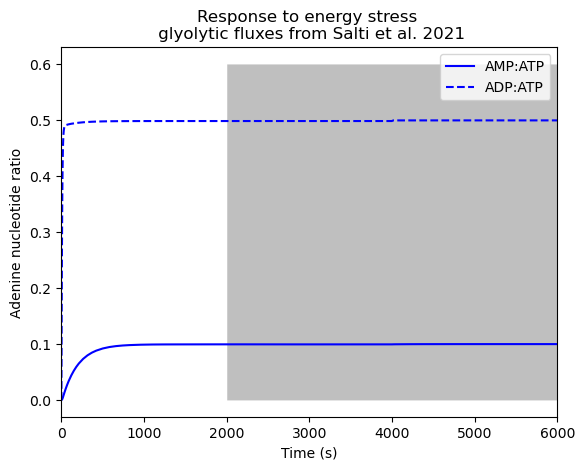

In [30]:
fig, ax = plt.subplots()
time = np.hstack((x_sol.t, x_sol.t[-1] + x_sol_pertubed.t))
ax.plot(time, 
    np.hstack((x_sol.y[0]/x_sol.y[2], x_sol_pertubed.y[0]/x_sol_pertubed.y[2])),
    'b')
ax.plot(time, 
    np.hstack((x_sol.y[1]/x_sol.y[2], x_sol_pertubed.y[1]/x_sol_pertubed.y[2])),
    'b--')

ax.fill_between(np.arange(2000, 6000), 0.0, 0.6, color='grey', alpha=0.5, lw=0)
ax.legend(['AMP:ATP', 'ADP:ATP'])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Adenine nucleotide ratio')
ax.tick_params(axis="y")
ax.set_xlim([0,6000])
# ax.set_ylim([0,0.55])
ax.set_title('Response to energy stress \n glyolytic fluxes from Salti et al. 2021')
fig.savefig('20230301_metaboloism_salti.pdf')

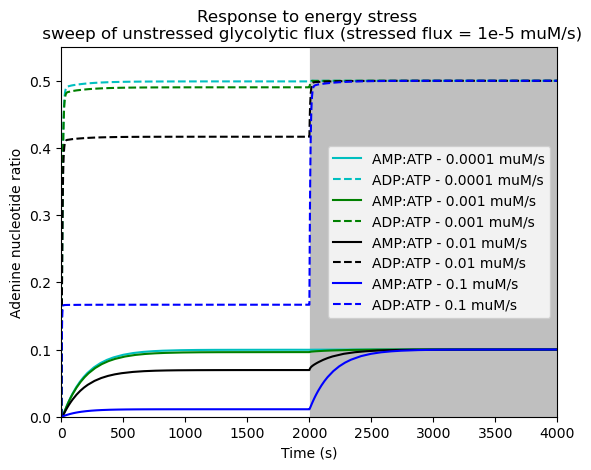

In [18]:
k_f_gly = 0.2 # muM/s or 0.014
k_f_gly_stressed = 1e-5 # 1/muM*s or 0.014

k_f_glys = [0.0001, 0.001, 0.01, 0.1] # muM/s or 0.014
x_sols = []
x_sols_stressed = []
for k_f_gly in k_f_glys:
    p = np.array([k_f_hydro, k_f_gly, k_f_adk, k_r_adk, k_f_batp])   
    tspan = (0, 2000)
    sol = solve_ivp(model_eqns, tspan, x0, args=([p]), method='BDF')
    x_sols.append(sol)
    x_steady_state = sol.y[:, -1]

    # Now, perturb glucose concentration and simulate from the new steady state.
    p_pert = np.array([k_f_hydro, k_f_gly_stressed, k_f_adk, k_r_adk, k_f_batp])   
    tspan = (0,2000)

    x_sols_stressed.append(solve_ivp(model_eqns, tspan, x_steady_state, args=([p_pert]), method='BDF'))

fig, ax = plt.subplots()
col = ['c', 'g', 'k', 'b']
for x_sol, x_sol_pertubed, col in zip(x_sols, x_sols_stressed, col): 
    time = np.hstack((x_sol.t, x_sol.t[-1] + x_sol_pertubed.t))
    ax.plot(time, 
        np.hstack((x_sol.y[0]/x_sol.y[2], x_sol_pertubed.y[0]/x_sol_pertubed.y[2])), col)
    ax.plot(time, 
        np.hstack((x_sol.y[1]/x_sol.y[2], x_sol_pertubed.y[1]/x_sol_pertubed.y[2])), col+'--')

ax.fill_between(np.arange(2000, 6000), 0.0, 0.6, color='grey', alpha=0.5, lw=0)
ax.legend(['AMP:ATP - 0.0001 muM/s', 'ADP:ATP - 0.0001 muM/s', 
           'AMP:ATP - 0.001 muM/s', 'ADP:ATP - 0.001 muM/s',
           'AMP:ATP - 0.01 muM/s', 'ADP:ATP - 0.01 muM/s',
           'AMP:ATP - 0.1 muM/s', 'ADP:ATP - 0.1 muM/s',], loc='best')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Adenine nucleotide ratio')
ax.tick_params(axis="y")
ax.set_xlim([0,4000])
ax.set_ylim([0,0.55])
ax.set_title('Response to energy stress \n sweep of unstressed glycolytic flux (stressed flux = 1e-5 muM/s)')
fig.savefig('20230301_metaboloism_sweep.pdf')

### Next, use the Coccimiglio model for Adenelyate Kinase and new model for glycolysis

0.0011202759053973244
40.44129729969229
0.001125070001052691
40.44265232301756
0.0011202759053973244
40.44129729969229
0.00112027590539829
40.44129729972714
0.0011202759387392769
40.44129729807244
0.001120275921516004
40.441297278944766
0.001150005804272457
40.44965455614533
0.0011500108977685768
40.4496560141957
0.001180141941890235
40.45801743533697
0.0011801479089706473
40.45801912236296
0.0015033658594624264
40.54179939206128
0.0015039609305611784
40.54194898435681
0.001867816454255026
40.626151917914704
0.0018685737196144584
40.626323596905806
0.0038102380728795493
40.978436906523385
0.0038096614957866745
40.97836820332762
0.00648559426808185
41.33813686773959
0.006486422388890093
41.33828215729552
0.009936362802838132
41.70628452217418
0.009937197899285407
41.7064087287232
0.03595249029653127
43.46182178854872
0.03594755928142899
43.46014156661257
0.0826285831528265
45.418305867525845
0.08265658607576681
45.416167704270535
0.1558163799307115
47.6138846560316
0.15586800778411325
4

ValueError: x and y must have same first dimension, but have shapes (142,) and (128,)

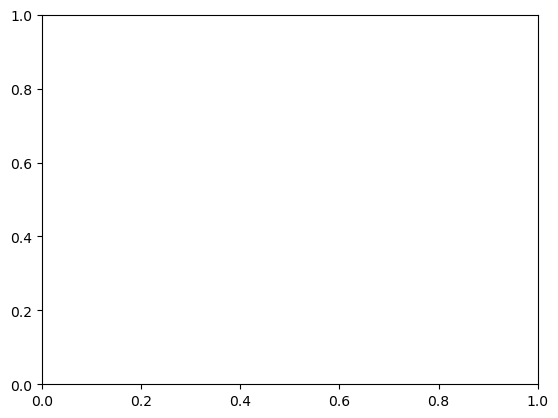

In [55]:
def coccimiglio_energ(t, x, p):
    k_f_hydro = p[0]
    k_f_gly = p[1]
    V_f_AK = p[2]
    kmt = p[3]
    kmm = p[4]
    kmd = p[5]
    K_eq_AK = p[6]
    V_max_OP = p[7]
    K_ADP = p[8]
    n = p[9]

    AMP = x[0]
    ADP = x[1]
    ATP = x[2]

    # fluxes
    Jhydro = k_f_hydro*ATP  # atp hydrolysis
    Jgly = 2*k_f_gly*ADP*ADP # glycolysis
    rAKFor = ((V_f_AK*ATP)/(kmt*kmm))/(1 + (ATP/kmt) + (AMP/kmm) + ((ATP*AMP)/(kmt*kmm)) + (2*ADP/kmd) + ((ADP/kmd)**2))
    V_r_AK = (V_f_AK*kmd*kmd)/(K_eq_AK*kmt*kmm)
    rAKrev = ((V_r_AK*ADP*ADP)/(kmd*kmd))/(1 + (ATP/kmt) + (AMP/kmm) + ((ATP*AMP)/(kmt*kmm)) + (2*ADP/kmd) + ((ADP/kmd)**2))
    JOxPhos = (V_max_OP*((ADP/K_ADP)**n))/(1 + ((ADP/K_ADP)**n) )

    print(rAKrev)
    print(rAKFor)
    # ode
    dxdt = np.zeros(x.shape)
    dxdt[0] = -rAKFor+rAKrev
    dxdt[1] = 2*rAKFor - 2*rAKrev - Jgly + Jhydro - JOxPhos
    dxdt[2] = -rAKFor + rAKrev + JOxPhos - Jhydro + Jgly

    return dxdt

# def coccimiglio_energ(t, x, p):
#     # fluxes
#     Jhydro = p[0]*x[2]  # atp hydrolysis
#     Jgly = p[1]*x[1]  # glycolysis
#     rAKfor = (p[2]*x[2])/(p[3]*p[4])/(1 + (x[2]/p[3]) + (x[0]/p[4]) + ((x[0]*x[2])/(p[3]*p[4])) + (2*x[1]/p[5]) + ((x[1]/p[5])**2))
#     VrevAK = ((p[2]*p[5]*p[5])/(p[6]*p[3]*p[4])) 
#     rAKrev = (VrevAK*((x[1]/p[5])**2))/(1 + (x[2]/p[3]) + (x[0]/p[4]) + ((x[0]*x[2])/(p[3]*p[4])) + (2*x[1]/p[5]) + ((x[1]/p[5])**2))
#     # JOxPhos = (p[7]*((x[1]/p[8])**p[9]))/(1 + ((x[1]/p[8])**p[9]))

#      # ode
#     dxdt = np.zeros(x.shape)
#     dxdt[0] = - rAKfor + rAKrev # AMP
#     dxdt[1] = Jhydro + 2*rAKfor - 2*rAKrev - 2*Jgly # ADP
#     dxdt[2] = 2*Jgly - rAKfor + rAKrev - Jhydro  # ATP

#     return dxdt

# p = [k_f_hydro, k_f_gly, V_f_AK, kmt, kmm, kmd, K_eq_AK]
k_f_hydro = 1.4e-3 # 1/s or 2.6e-2
k_f_gly = 0 #.617 # 1/mM*s
# k_f_gly = 0.02 # muM/s or 0.014
k_f_gly_stressed = 0 #.225 # 1/mM*s or 0.014
V_f_AK = 14.66 # mM/s
kmt = 0.27 # mM
kmm = 0.35 # mM
kmd = 0.32 # mM
K_eq_AK = 0.744 # unitless or 0.744 from model fit
V_max_OP = 0.5 # mM/s
K_ADP = 5.8e-2 # mM
nH = 2.568 # unitless

p = np.array([k_f_hydro, k_f_gly, V_f_AK, kmt, kmm, kmd, K_eq_AK, V_max_OP, K_ADP, nH])
p_perturbed = np.array([k_f_hydro, k_f_gly_stressed, V_f_AK, kmt, kmm, kmd, K_eq_AK, V_max_OP, K_ADP, nH])

# x = [AMP, ADP, ATP]
AMPic = 2.03e-5 # mM or 4.44e-4
ADPic = 1.3e-2 # mM or 5.68e-2
ATPic = 8.2 # mM or 7.66
x0 = np.array([AMPic, ADPic, ATPic])

tspan = (0, 6000)
x_sol = solve_ivp(coccimiglio_energ, tspan, x0, args=([p]), method='BDF')
x_steady_state = x_sol.y[:, -1]

# Now, perturb glucose concentration and simulate from the new steady state.
x_sol_pertubed = solve_ivp(coccimiglio_energ, tspan, x_steady_state, args=([p_perturbed]), method='BDF')

fig, ax = plt.subplots()
# time = np.hstack((x_sol.t, x_sol.t[-1] + x_sol_pertubed.t))

# ax.plot(time, 
#     np.hstack((x_sol.y[0], x_sol_pertubed.y[0])),
#     'b')
# ax.plot(time, 
#     np.hstack((x_sol.y[1], x_sol_pertubed.y[1])),
#     'b--')
# ax.plot(time, 
#     np.hstack((x_sol.y[2], x_sol_pertubed.y[2])),
#     'b:')

ax.plot(time, 
        np.hstack((x_sol.y[0]/x_sol.y[2], x_sol_pertubed.y[0]/x_sol_pertubed.y[2])), 'b')
ax.plot(time, 
    np.hstack((x_sol.y[1]/x_sol.y[2], x_sol_pertubed.y[1]/x_sol_pertubed.y[2])),'b--')

# ax.legend(['AMP:ATP', 'ADP:ATP'])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Adenine nucleotide ratio', color='b')
ax.tick_params(axis="y", labelcolor='b')
ax.set_title('Leung model: Response to reduction in Glucose concentration')

